In [1]:
# Using https://github.com/DeepLearnPhysics/spine-workshop-2026/blob/main/basics/larcv/LArCV_visualization.ipynb for reference to look at LARCV files. 
import larcv
import ROOT
import sys
sys.path.insert(0, '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/spine/')
import spine
from spine.io.dataset.larcv import LArCVDataset


fname = '/pscratch/sd/e/ehinkle/nd_ana/sheep_single_shower/NDLAR_ELECTRON_SAMPLES/LARCV/TRAIN/electron_NDLAr_10MeVto15GeV_1008TEST.1675.LARCV.root' # Change this path if you are not on NERSC
#fname = 'LOCAL_PATH'
f = ROOT.TFile(fname)
f.ls()

Welcome to JupyROOT 6.26/16
TFile**		/pscratch/sd/e/ehinkle/nd_ana/sheep_single_shower/NDLAR_ELECTRON_SAMPLES/LARCV/TRAIN/electron_NDLAr_10MeVto15GeV_1008TEST.1675.LARCV.root	
 TFile*		/pscratch/sd/e/ehinkle/nd_ana/sheep_single_shower/NDLAR_ELECTRON_SAMPLES/LARCV/TRAIN/electron_NDLAr_10MeVto15GeV_1008TEST.1675.LARCV.root	
  KEY: TTree	particle_pcluster_tree;2	pcluster tree [current cycle]
  KEY: TTree	particle_pcluster_tree;1	pcluster tree [backup cycle]
  KEY: TTree	sparse3d_pcluster_tree;1	pcluster tree
  KEY: TTree	sparse3d_pcluster_semantics_tree;1	pcluster_semantics tree
  KEY: TTree	cluster3d_pcluster_tree;1	pcluster tree
  KEY: TTree	cluster3d_pcluster_dedx_tree;1	pcluster_dedx tree


In [2]:
import uproot

tree = uproot.open(fname)
tree.keys()

['particle_pcluster_tree;2',
 'particle_pcluster_tree;1',
 'sparse3d_pcluster_tree;1',
 'sparse3d_pcluster_semantics_tree;1',
 'cluster3d_pcluster_tree;1',
 'cluster3d_pcluster_dedx_tree;1']

In [3]:
import numpy as np
tree = f.Get("cluster3d_pcluster_tree")
print('Number of entries', tree.GetEntries())

for entry in range(tree.GetEntries()):
    tree.GetEntry(entry)
    event = tree.cluster3d_pcluster_branch
    clusters = event.as_vector()
    print("Number of clusters = ", len(clusters))
    cluster_sizes = []
    for c in clusters:
        cluster_sizes.append(c.as_vector().size())
    print(np.sum(np.array(cluster_sizes)))

Number of entries 50
Number of clusters =  14781
28651
Number of clusters =  14999
30157
Number of clusters =  8999
17498
Number of clusters =  7362
14231
Number of clusters =  3374
6455
Number of clusters =  9718
18884
Number of clusters =  5599
10835
Number of clusters =  1694
3204
Number of clusters =  14909
29362
Number of clusters =  10404
19613
Number of clusters =  12123
23602
Number of clusters =  6522
12716
Number of clusters =  358
682
Number of clusters =  6326
12367
Number of clusters =  6082
11484
Number of clusters =  6019
11550
Number of clusters =  3635
6909
Number of clusters =  12474
24214
Number of clusters =  12220
24326
Number of clusters =  8422
16148
Number of clusters =  10538
20108
Number of clusters =  5399
10529
Number of clusters =  1586
3069
Number of clusters =  90
179
Number of clusters =  48
86
Number of clusters =  1802
3457
Number of clusters =  5609
10718
Number of clusters =  10273
19918
Number of clusters =  6233
11891
Number of clusters =  2021
383

In [4]:
tree = f.Get("particle_pcluster_tree")
print('Number of entries', tree.GetEntries())
energy_init_values = []
start_x = []
start_y = []
start_z = []

for entry in range(tree.GetEntries()):
    tree.GetEntry(entry)
    event = tree.particle_pcluster_branch
    #print("Event:", event)
    particles = event.as_vector()
    #print("Number of particles = ", len(particles))
    energy_init_values.append(particles[0].energy_init())
    start_x.append(particles[0].x())
    start_y.append(particles[0].y())
    start_z.append(particles[0].z())

print("Energy init values:", energy_init_values)
print("Start x:", start_x)
print("Start y:", start_y)
print("Start z:", start_z)
energy_init_values = np.array(energy_init_values)
start_x = np.array(start_x)
start_y = np.array(start_y)
start_z = np.array(start_z)
    

Number of entries 50
Energy init values: [13990.028086038703, 14519.114091152709, 8402.24892979706, 6769.392749230612, 3020.3237320473886, 9075.17813188925, 5092.80697433667, 1468.3222343647615, 14279.746814425242, 9357.986793461605, 11436.363707991979, 5972.595771299093, 299.4512973930159, 5897.313248943403, 5377.933563821992, 5382.6369391781855, 3179.5330960950914, 11822.884298633926, 11882.477007961525, 7564.846985216884, 9535.2092842871, 4960.823345508471, 1395.3920414124348, 77.44499212221845, 40.935646363269754, 1602.6283797292283, 4902.164940774679, 9548.63388463891, 5454.8627128967055, 1763.21008733181, 9312.624192295485, 5305.5758520089885, 11296.322950154548, 3849.12759350037, 4100.734849775034, 13644.922091615485, 11910.754930833387, 2777.8057098097593, 5256.302861207677, 3180.1887778476266, 10823.8395350179, 13061.668701685576, 12804.907959153876, 7914.060057314491, 6178.006397691605, 8332.758053623236, 8385.71871896921, 7052.1293254362645, 1620.1682544211553, 7866.97250449

Number of entries 50
Entry: 127288
Number of sparse3d =  10594
Total event value sums: [4901.83688959]
Position x start: [40.54908671552403, 7.812209367210926, 7.068189427476682, 7.440199397343349, 7.440199397343349, 7.812209367210926, 8.928239276812747, 10.416279156281234, 82.58621331051654, 82.58621331051654, 43.153156504594335, 81.8421933707823, 43.153156504594335, 38.317026896320385, 12.2763290056173, 37.57300695658614, 11.904319035749722, 87.05033294892291, 84.4462631598526, 7.812209367210926, 44.64119638406282, 37.57300695658614, 37.57300695658614, 37.57300695658614, 92.63048249693111, 92.25847252706353, 50.593355901937684, 49.84933596220344, 49.84933596220344, 50.22134593207102, 52.08139578140708, 52.45340575127375, 50.22134593207102, 85.9343030393211, 57.2895353595477, -26.78471783043824, -24.924667981102175, -24.924667981102175, -20.088538372828225, 56.91752538968012, -12.648338975484876, -13.764368885086697, -9.300249246680323, -26.040697890703996, -27.528737770172484, 81.470

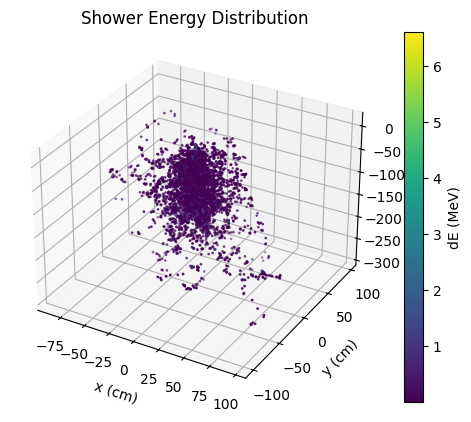

In [5]:
import numpy as np
tree = f.Get("sparse3d_pcluster_tree")
print('Number of entries', tree.GetEntries())
total_event_value_sum = []
pos_x_start = []
pos_y_start = []
pos_z_start = []


for entry in range(tree.GetEntries()):
    if entry != 26:
        continue
    tree.GetEntry(entry)
    print("Entry:", tree.GetEntry(entry))
    event = tree.sparse3d_pcluster_branch
    #print("Event:", event)
    #print("Event Meta:", event.meta())
    event_meta = event.meta()
    #print("Event meta().dump():", event.meta().dump())
    sparse3d = event.as_vector()
    #print("Sparse3D:", sparse3d)
    print("Number of sparse3d = ", len(sparse3d))
    sparse3d_ids = []
    sparse3d_values = []
    idx = 0
    for s in sparse3d:
        sid = s.id()
        position_x = event_meta.pos_x(sid)
        position_y = event_meta.pos_y(sid)
        position_z = event_meta.pos_z(sid)
        pos_x_start.append(position_x)
        pos_y_start.append(position_y)
        pos_z_start.append(position_z)
        #print("Position:", position_x, position_y, position_z)
        sparse3d_values.append(s.value())
        idx += 1
        #print("Value:", s.value())
        #break
    #print(np.array(sparse3d_ids))
    total_event_value_sum.append(np.sum(np.array(sparse3d_values)))

print("Total event value sums:", np.array(total_event_value_sum))
print("Position x start:", pos_x_start)
print("Position y start:", pos_y_start)
print("Position z start:", pos_z_start) 
pos_x_start = np.array(pos_x_start)
pos_y_start = np.array(pos_y_start) 
pos_z_start = np.array(pos_z_start)

import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

shower = ax.scatter(pos_x_start,pos_y_start, pos_z_start, c=sparse3d_values, cmap='viridis', s=1)
ax.set_xlabel('x (cm)')
ax.set_ylabel('y (cm)')
ax.set_zlabel('z (cm)')
ax.set_title('Shower Energy Distribution')
plt.colorbar(shower, ax=ax, label='dE (MeV)')
plt.show()

In [6]:
# Check against original edep-sim hdf5 file: 
import h5py 
# Get shower data function 
def get_shower_data(sim_h5, event_id):

    parse_var='event_id'
    seg_var='segments'     

    traj_spill_mask = sim_h5['trajectories'][:][parse_var]==event_id
    seg_spill_mask = sim_h5[seg_var][:][parse_var]==event_id
    event_mask = sim_h5['events'][:][parse_var]==event_id

    traj = sim_h5['trajectories'][traj_spill_mask]
    seg = sim_h5[seg_var][seg_spill_mask]
    event = sim_h5['events'][event_mask]

    return traj, seg, event

In [7]:
edep_sim_file = "/pscratch/sd/e/ehinkle/nd_ana/sheep_single_shower/NDLAR_ELECTRON_SAMPLES/CONVERT2H5/electron_NDLAr_10MeVto15GeV_TEST5.1002.CONVERT2H5.hdf5"
#edep_sim_file = "/pscratch/sd/e/ehinkle/nd_ana/sheep_single_shower/ELECTRON_SAMPLES/CONVERT2H5/TEST/electron_positron_10MeVto2GeV.8947.CONVERT2H5.hdf5"
sim_h5 = h5py.File(edep_sim_file, 'r')
event_energy = []
total_seg_energy = []

num_events = len(np.unique(sim_h5['events']['event_id']))
for event_id in range(num_events):
    traj, seg, events = get_shower_data(sim_h5, event_id)
    event_energy.append(events['E_start'][0])
    total_seg_energy.append(np.sum(seg['dE']))


event_energy = np.array(event_energy)
total_seg_energy = np.array(total_seg_energy)
print("Total segment energy:", total_seg_energy)

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/pscratch/sd/e/ehinkle/nd_ana/sheep_single_shower/NDLAR_ELECTRON_SAMPLES/CONVERT2H5/electron_NDLAr_10MeVto15GeV_TEST5.1002.CONVERT2H5.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [8]:
total_event_value_sum = np.array(total_event_value_sum)

diff_event_val_sum_total_seg_energy = total_event_value_sum - total_seg_energy
diff_energy_init_values_event_energy = energy_init_values - event_energy
#print("Event energy:", event_energy)
#print("Energy init values:", energy_init_values)
print("Difference between total event value sum and total segment energy:", diff_event_val_sum_total_seg_energy)
print("Difference between energy init LARCV and event energy edep-sim:", diff_energy_init_values_event_energy)

Difference between total event value sum and total segment energy: [-2.64560030e+02 -7.06252365e+03 -2.40802951e+03 -1.03656682e+04
 -2.37755979e+03 -9.77845432e+03 -9.64552854e+03 -3.02602219e+03
 -2.80812180e+03 -2.10539475e+03  1.60187942e+03 -1.11065949e+04
 -1.09925002e+04 -9.18792014e+03 -5.58765061e+03 -6.44303635e+03
 -2.11731613e+03  4.24358183e+02 -5.81135861e+03 -6.00987033e+03
 -1.43300852e+03 -2.63959445e+03 -3.78011789e+03 -7.65819260e+03
 -6.39376193e+03 -5.02086936e+03  2.85713368e-05 -3.84893967e+03
 -5.28223606e+03  2.06228433e+03 -7.66180393e+03 -7.19892502e+03
 -8.60755393e+03 -4.96220920e+03 -9.92439768e+03 -7.83006563e+02
 -6.05839084e+03 -1.54067063e+03 -1.06028108e+04 -1.03282492e+04
  1.32207290e+03 -5.24539278e+02  8.09126738e+02 -9.70509493e+02
 -7.92514865e+03 -2.89394259e+02 -8.93759981e+02  9.62967558e+02
 -2.44375704e+02 -8.77348654e+03]
Difference between energy init LARCV and event energy edep-sim: [-4.69315419e-05 -4.24032365e-04 -1.72599337e-04 -1.679

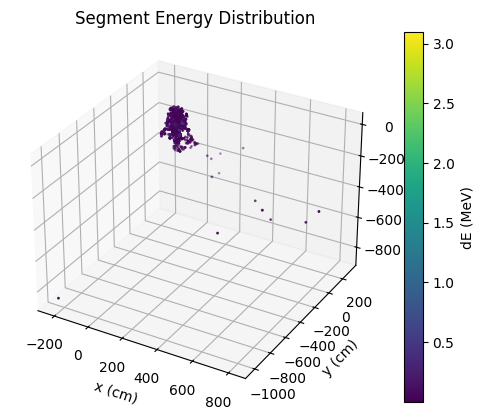

[[0.9748668 ]
 [1.6086833 ]
 [1.7011578 ]
 ...
 [0.03253315]
 [0.26575103]
 [0.14156896]]
Segment positions: [[-2.7143600e-04 -1.8697858e-04 -2.8926247e-01]
 [-1.2720362e-03 -9.4990840e-04 -9.7455508e-01]
 [-3.3100238e-03 -1.8503999e-03 -1.7913272e+00]
 ...
 [-8.4567353e-02 -3.9647952e-02 -2.7333839e+01]
 [ 1.3718651e-02 -8.3633959e-03 -5.8886886e-01]
 [ 2.4713743e-02 -1.7725833e-02 -5.9973520e-01]]


In [9]:
traj, seg, events = get_shower_data(sim_h5, 26)
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

shower = ax.scatter(seg['x'], seg['y'], seg['z'], c=seg['dE'], cmap='viridis', s=1)
ax.set_xlabel('x (cm)')
ax.set_ylabel('y (cm)')
ax.set_zlabel('z (cm)')
ax.set_title('Segment Energy Distribution')
plt.colorbar(shower, ax=ax, label='dE (MeV)')
plt.show()
print(np.array([seg['dE']]).T)
segment_positions = np.array([seg['x'], seg['y'], seg['z']]).T 
print("Segment positions:", segment_positions)

In [10]:
# Access LARCV file with parser
DATA_PATH = fname
ENTRY = "["+str(10)+"]" # Change this to access different entries in the LARCV file.
NUM_WORKERS = 4

cfg = """
base:
  verbosity: info
io:
  loader:
    batch_size: 1
    shuffle: False
    num_workers: NUM_WORKERS
    collate_fn: all
    dataset:
      name: larcv
      file_keys: DATA_PATH
      entry_list: ENTRY
      schema:
        input_data:
          parser: sparse3d
          sparse_event: sparse3d_pcluster
        particles:
          parser: particle
          particle_event: particle_pcluster
          sparse_event: sparse3d_pcluster
        meta:
          parser: meta
          sparse_event: sparse3d_pcluster
""".replace('DATA_PATH', DATA_PATH).replace('ENTRY', str(ENTRY)).replace('NUM_WORKERS', str(NUM_WORKERS))

print(cfg)


base:
  verbosity: info
io:
  loader:
    batch_size: 1
    shuffle: False
    num_workers: 4
    collate_fn: all
    dataset:
      name: larcv
      file_keys: /global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/sample_gen/electron_NDLAr_10MeVto15GeV_TEST5.1002.LARCV.root
      entry_list: [10]
      schema:
        input_data:
          parser: sparse3d
          sparse_event: sparse3d_pcluster
        particles:
          parser: particle
          particle_event: particle_pcluster
          sparse_event: sparse3d_pcluster
        meta:
          parser: meta
          sparse_event: sparse3d_pcluster



In [11]:
import yaml
import sys 
sys.path.append("/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/spine")
import spine
from spine.driver import Driver

cfg = yaml.safe_load(cfg)



In [12]:
driver = Driver(cfg)
data = driver.process()


 ██████████   ██████████    ███   ███       ██   ███████████
███        █  ██       ███   █    █████     ██   ██         
  ████████    ██       ███  ███   ██  ████  ██   ██████████ 
█        ███  ██████████     █    ██     █████   ██         
 ██████████   ██            ███   ██       ███   ███████████

Release version: 0.10.3

$CUDA_VISIBLE_DEVICES=None

Configuration processed at: Linux login11 6.4.0-150600.23.73_15.0.14-cray_shasta_c #1 SMP Tue Oct 21 20:32:25 UTC 2025 (89d3c98) x86_64 x86_64 x86_64 GNU/Linux

base: {verbosity: info, world_size: 0, seed: 1776711920}
io:
  loader:
    batch_size: 1
    shuffle: false
    num_workers: 4
    collate_fn: all
    dataset:
      name: larcv
      file_keys: /global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/sample_gen/electron_NDLAr_10MeVto15GeV_TEST5.1002.LARCV.root
      entry_list: [10]
      schema:
        input_data: {parser: sparse3d, sparse_event: sparse3d_pcluster}
        particles: {parser: particle, particle_

Will load 1 file(s):
 - /global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/sample_gen/electron_NDLAr_10MeVto15GeV_TEST5.1002.LARCV.root

Loading tree sparse3d_pcluster
Loading tree particle_pcluster

Total number of entries in the file(s): 50

Total number of entries selected: 1



In [13]:
event_id = 0

# Get true energy:
particles = data['particles'][event_id]
print("Particles:", particles[0])
true_energy = particles[0].energy_init
true_KE = particles[0].p
print("True energy:", true_energy)
print("True kinetic energy:", true_KE)

# Get positions and energies for each filled voxel:
positions = data['input_data'][event_id][:,1:4]
energy_per_voxel = data['input_data'][event_id][:,4]
input_data_full = data['input_data'][event_id]

print("Input data:", input_data_full)
print("Positions (voxel):", positions)
print("Energy per voxel:", energy_per_voxel)

# Get positions for each filled voxel (actual x, y, z coordinates):
meta = data['meta'][event_id]
positions_cm = meta.to_cm(positions, center=True)
print("Positions (cm):", positions_cm/10)
print(np.array([[i] for i in energy_per_voxel]))


Particles: Particle(id=0, mct_index=65535, mcst_index=65535, group_id=np.int64(0), interaction_id=np.int64(0), nu_id=np.int64(-1), interaction_primary=np.int64(1), group_primary=np.int64(1), parent_id=np.int64(0), children_id=array([], dtype=int64), track_id=0, parent_track_id=0, ancestor_track_id=np.int64(0), pid=np.int64(1), pdg_code=-11, parent_pdg_code=-11, ancestor_pdg_code=-11, num_voxels=702, shape=0, energy_init=1107.3664340896853, energy_deposit=520.9133911132812, distance_travel=566.2025896974413, creation_process='2::22', parent_creation_process='2::22', ancestor_creation_process='2::22', t=1000.0, end_t=2903.4024729999996, parent_t=1000.0, ancestor_t=1000.0, position=array([13440.5, 13440.5, 13440.5], dtype=float32), end_position=array([13461.714, 13451.577, 13300.913], dtype=float32), parent_position=array([13440.5, 13440.5, 13440.5], dtype=float32), ancestor_position=array([13440.5, 13440.5, 13440.5], dtype=float32), first_step=array([-2.4793347e+13, -2.4793347e+13, -2.47

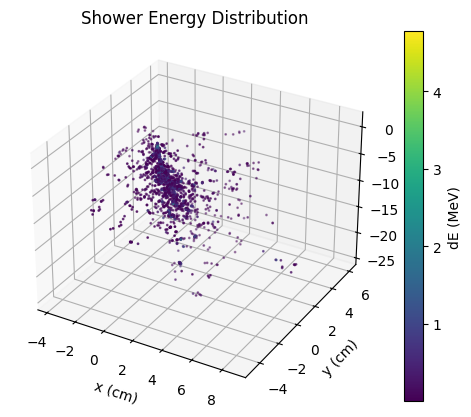

In [14]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

shower = ax.scatter(positions_cm[:,0]/10,positions_cm[:,1]/10,positions_cm[:,2]/10, c=energy_per_voxel, cmap='viridis', s=1)
ax.set_xlabel('x (cm)')
ax.set_ylabel('y (cm)')
ax.set_zlabel('z (cm)')
ax.set_title('Shower Energy Distribution')
plt.colorbar(shower, ax=ax, label='dE (MeV)')
plt.show()

In [16]:
# Copied from https://github.com/NERSC/nersc-dl-multigpu/blob/main/utils/YParams.py

import yaml

class ParseYAML():
    """ Yaml file parser """
    def __init__(self, yaml_filename, config_name, print_params=False):
        self._yaml_filename = yaml_filename
        self._config_name = config_name
        self.params = {}

        if print_params:
            print("------------------ Configuration ------------------")

        with open(yaml_filename) as _file:

            config = yaml.safe_load(_file)[config_name]
            for key, val in config.items():
                if print_params: print(key, val)
                if val =='None': val = None

                self.params[key] = val
                self.__setattr__(key, val)

        if print_params:
            print("---------------------------------------------------")

    def __getitem__(self, key):
        return self.params[key]

    def __setitem__(self, key, val):
        self.params[key] = val
        self.__setattr__(key, val)
    
    def __contains__(self, key):
        return (key in self.params)

    def update_params(self, config):
        for key, val in config.items():
            self.params[key] = val
            self.__setattr__(key, val)

    def log(self):
        print("------------------ Configuration ------------------")
        print("Configuration file: "+str(self._yaml_filename))
        print("Configuration name: "+str(self._config_name))
        for key, val in self.params.items():
            print(str(key) + ' ' + str(val))
        print("---------------------------------------------------")

In [8]:
# Modeled after: https://github.com/NERSC/nersc-dl-multigpu/blob/main/utils/data_loader.py

from curses import meta

import torch
from torch.utils.data import DataLoader, Dataset, get_worker_info
from torch.utils.data.distributed import DistributedSampler
import numpy as np
import sys
import subprocess
import os

import sys
sys.path.insert(0, '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/spine/')
import spine
from spine.driver import Driver
import yaml
import larcv
import ROOT
import uproot

def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])
try: 
    import h5py
except ImportError:
    install('h5py')
    import h5py

import glob

# Get data loader
def get_data_loader(params, data_location, distributed, train=True, test=False):
    """Function to get the data loader for training/validation/testing."""
    mode = 'train' if train else 'valid' if not test else 'test'

    dataset = ShowerDataset(params, data_location, mode=mode)
    # define a sampler for distributed training using DDP
    sampler = DistributedSampler(dataset, shuffle=train, drop_last=True) if distributed else None
    batch_size = int(params.local_batch_size if train else params.local_valid_batch_size if not test else params.local_test_batch_size)

    dataloader = DataLoader(dataset,
                            batch_size=batch_size,
                            num_workers=params.num_data_workers,
                            shuffle=(sampler is None and train), # Don't shuffle validation/test data
                            sampler=sampler,
                            collate_fn=shower_collate_fn,
                            drop_last=True,
                            pin_memory=torch.cuda.is_available(), 
                            timeout=600) # timeout to prevent hanging

    return dataloader, sampler

segments_event_data_dtype = np.dtype([
    ('dE', np.float32),  # Energy deposit
    ('x', np.float32),   # X coordinate
    ('y', np.float32),   # Y coordinate
    ('z', np.float32)    # Z coordinate
])

# Dataset collate function for batching
def shower_collate_fn(batch): 
    """Collate function to combine multiple samples into a batch."""
    #coords_list = []
    #features_list = []
    data_list = []
    labels_list = []
    ve_frac_list = []
    mg_frac_list = []
    oob_frac_list = []
    start_pos_list = []
    rot_mat_list = []

    for batch_idx, (data, label, VE_frac, MG_frac, OOB_frac, start_pos, rot_mat) in enumerate(batch):
        # Set batch index
        batch_data = data.clone()
        #print("Batch data shape:", batch_data.shape)
        batch_data[:, 0] = batch_idx  # Set batch index to the first column

        data_list.append(batch_data)

        labels_list.append(label)
        ve_frac_list.append(VE_frac)
        mg_frac_list.append(MG_frac)
        oob_frac_list.append(OOB_frac)
        start_pos_list.append(start_pos)
        rot_mat_list.append(rot_mat)
    
    # Concatenate all coordinates and features into single tensors
    batched_data = torch.cat(data_list, dim=0)
    batched_labels = torch.stack(labels_list, dim=0).reshape(-1, 1) # ESSENTIAL -- ensures output and labels are same shape
    batched_ve_frac = torch.stack(ve_frac_list, dim=0).reshape(-1, 1)
    batched_mg_frac = torch.stack(mg_frac_list, dim=0).reshape(-1, 1)
    batched_oob_frac = torch.stack(oob_frac_list, dim=0).reshape(-1, 1)
    batched_start_pos = torch.stack(start_pos_list, dim=0) # Shape (B, 3)
    batched_rot_mat = torch.stack(rot_mat_list, dim=0) # Shape (

    #print("Batched data:", batched_data)

    return batched_data, batched_labels, batched_ve_frac, batched_mg_frac, batched_oob_frac, batched_start_pos, batched_rot_mat


class ShowerDataset(Dataset):
         
    def __init__(self, params, data_location, mode='train'):

        """
        Args:
            params:                Parameters from yaml file
            data_location:         Path to dataset directory
            mode:                  'train' | 'valid' | 'test' 
        """

        self.mode = mode
        self.num_workers = params.num_data_workers
       
        self._file_dir = data_location
        # Set num_files for train/validation/test based on mode
        self._num_files_train = params.train_files
        self._num_files_val = params.val_files
        self._num_files_test = params.test_files
        self._set_dataset_file_list()  # Get list of files in dataset directory
        self._set_events_per_file()  # Get number of events per file + file indices

        self._detector_active_regions = np.array(params.detector_active_regions)
        self._RANDOM_SEED = int(params.random_seed)
        self._voxel_size = np.array(params.voxel_size)
        self._min_visible_energy = params.min_visible_energy  # For numerical stability in MinkowskiEngine (Minimum energy target) 
        self._fid_vol_cut = params.fid_vol_cut  # Fiducial volume cut in cm
        self._train_logE = params.train_logE  # Whether to take log of energy for training targets (for better training stability)

        # Get min and max bounds for each detector module
        self._min_bounds = self._detector_active_regions[:, 0, :] # Shape (M, 3) where M is the number of detector modules/active volumes
        self._max_bounds = self._detector_active_regions[:, 1, :] # Shape (M, 3) where M is the number of detector modules/active volumes

        # Set min/max coordinates and number of voxels
        self._min_xyz = np.array([np.min(self._detector_active_regions[:, :, 0]), 
                                  np.min(self._detector_active_regions[:, :, 1]),
                                  np.min(self._detector_active_regions[:, :, 2])])
        self._max_xyz = np.array([np.max(self._detector_active_regions[:, :, 0]),
                                  np.max(self._detector_active_regions[:, :, 1]),
                                  np.max(self._detector_active_regions[:, :, 2])])
        self._num_voxels = np.ceil((self._max_xyz - self._min_xyz) / self._voxel_size).astype(int)


        # Set random seeds for reproducibility
        # Use local generators vs. global to avoid interference between workers and encourage reproducibility
        #self._train_rng = np.random.default_rng(self._RANDOM_SEED)
        #np.random.seed(self._RANDOM_SEED)
        #torch.manual_seed(self._RANDOM_SEED)
        self._epoch = 0
        #self._train_rng = np.random.default_rng(self._RANDOM_SEED)
        self._train_rng = None

        # Set torch device
        #self._device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        #print(f"Using device: {self._device}")
        #torch.device(self._device)

    def __len__(self):
        return np.sum(self._events_per_file)

    def __getitem__(self, idx):

        file_idx, event_local_idx = self._decode_idx(idx)  # Decode the global index into file and event indices
        
        #print(f"Loading file: {h5_file_name}, File index: {file_idx}, Event local index: {event_local_idx}")  # Debugging line to check which file and event is being loaded
        #print(f"Event global index: {idx}")  # Debugging line to check global index being loaded

        '''with h5py.File(h5_file_name, 'r') as h5_file:  # Open the HDF5 file
            file_events = h5_file['events']  # Access the events dataset
            file_segments = h5_file['segments']
            file_segments_refs = h5_file['segments_ref']

            event = file_events[event_local_idx]
            event_id = int(event['event_id'])
            segments = file_segments[file_segments_refs[event_id]]

            true_KE_initial = float(np.sqrt(np.sum(np.square(event['pxyz_start']))))

            # Same for train/validation/test now
            rng = self._get_deterministic_rng_per_event(idx)
            #print(f"Event ID: {idx}, RNG state: {rng.bit_generator.state}")  # Debugging line to check RNG state for each event
            vis_segs, ve_frac, mg_frac, oob_frac, start_pos, rot_mat = self._get_filtered_segments(rng, segments, true_KE_initial, self._min_visible_energy)'''

        # Accessing LARCV files using SPINE parsers
        DATA_PATH = self._file_list[file_idx]
        ENTRY = "["+str(event_local_idx)+"]" # Change this to access different entries in the LARCV file.
        NUM_WORKERS = 0

        cfg = """
            base:
              verbosity: warning
            io:
              loader:
                batch_size: 1
                shuffle: False
                num_workers: NUM_WORKERS
                collate_fn: all
                dataset:
                  name: larcv
                  file_keys: DATA_PATH
                  entry_list: ENTRY
                  schema:
                    input_data:
                      parser: sparse3d
                      sparse_event: sparse3d_pcluster
                    particles:
                      parser: particle
                      particle_event: particle_pcluster
                      sparse_event: sparse3d_pcluster
                    meta:
                      parser: meta
                      sparse_event: sparse3d_pcluster
            """.replace('DATA_PATH', DATA_PATH).replace('ENTRY', str(ENTRY)).replace('NUM_WORKERS', str(NUM_WORKERS))
            
        cfg = yaml.safe_load(cfg)
        driver = Driver(cfg)
        data = driver.process()

        # Assume one event loaded at a time
        particles = data['particles'][0]
        true_KE_initial = float(particles[0].p)

        # Get positions and energies for each filled voxel:
        energy_per_voxel = data['input_data'][0][:,4]
        energy_per_voxel = np.array([[i] for i in energy_per_voxel])
        positions = data['input_data'][0][:,1:4]
        meta = data['meta'][0]
        positions_cm = np.array(meta.to_cm(positions, center=True))

        # Same for train/validation/test now
        rng = self._get_deterministic_rng_per_event(idx)
        #print(f"Event ID: {idx}, RNG state: {rng.bit_generator.state}")  # Debugging line to check RNG state for each event
        vis_segs, ve_frac, mg_frac, oob_frac, start_pos, rot_mat = self._get_filtered_segments(rng, positions_cm, energy_per_voxel, true_KE_initial, self._min_visible_energy)

        
        # Voxelize the filtered segments SPARSELY
        coords, features = self._voxelize_sparse(vis_segs)

        # Convert coords, features, labels, to PyTorch tensors
        coords = torch.from_numpy(coords).contiguous()  # Keep as int32 for voxel indices
        features = torch.from_numpy(features).contiguous()  # Already float32
        combined_data = torch.cat([coords.float(), features], dim=1)  # Convert coords to float only for concatenation

        #true_KE_initial_tensor = torch.tensor(true_KE_initial / 1000.0, dtype=torch.float32) # Convert to GeV
        # Instead of converting to GeV, take log of energy to target output range
        true_KE_initial_tensor = torch.tensor(true_KE_initial, dtype=torch.float32) 
        if self._train_logE == True:
            true_KE_initial_tensor = torch.tensor(true_KE_initial, dtype=torch.float32) 
            true_KE_initial_tensor = torch.log(true_KE_initial_tensor)  
        else:
            true_KE_initial_tensor = torch.tensor(true_KE_initial / 1000.0, dtype=torch.float32) # Convert to GeV
        #print("Took log of true KE initial for better training stability. Original KE:", true_KE_initial, "Log KE:", true_KE_initial_tensor.item())
        # Convert energy fractions to torch tensors
        ve_frac_tensor = torch.tensor(ve_frac, dtype=torch.float32)
        mg_frac_tensor = torch.tensor(mg_frac, dtype=torch.float32)
        oob_frac_tensor = torch.tensor(oob_frac, dtype=torch.float32)
        start_pos_tensor = torch.tensor(start_pos, dtype=torch.float32)
        rot_mat_tensor = torch.tensor(rot_mat, dtype=torch.float32)
        #print("Start point:", start_pos_tensor)
        ##print("Rotation matrix:", rot_mat_tensor)


        return combined_data, true_KE_initial_tensor, ve_frac_tensor, mg_frac_tensor, oob_frac_tensor, start_pos_tensor, rot_mat_tensor


    # Method to get file_idx, event_idx pair from global idx
    def _decode_idx(self, idx):
        """Decode a global index into a file index and an event index."""
        file_idx = np.digitize(idx, self._event_total_by_file) - 1  # Find the file index
        #print("File index:", file_idx)  # Debugging line to check file index
        event_idx = idx - self._event_total_by_file[file_idx]  # Find the event index within that file
        return file_idx, event_idx
    
    # Set deterministic rng per event for validation/testing
    def _get_deterministic_rng_per_event(self, event_id: int):
        """Get a deterministic random number generator for a given event and epoch for determinstic poses."""
        if self.mode == 'train' or self.mode == 'test':
            mixed_seed = (self._RANDOM_SEED * 1_000_0003) ^ (int(event_id) * 97) ^ (int(self._epoch) * 1_000_000 + 1337)
        elif self.mode == 'valid':
            mixed_seed = (self._RANDOM_SEED * 1_000_0003) ^ (int(event_id) * 97)
        return np.random.default_rng(np.uint64(mixed_seed & 0xFFFFFFFFFFFFFFFF))  # Ensure seed fits in uint64

    # Method to convert random start position and start direction to set of filtered visible depositions
    def _get_filtered_segments(self, rng, positions, energy_per_larcv_voxel, true_KE_initial, min_visible_energy=5.0):
        ''' Method to convert random start position and start direction to set of filtered visible depositions
        Inputs:
            - rng: random number generator (different for train/val/test for reproducibility)
            - positions: array of voxel x, y, z positions (cm)
            - energy_per_larcv_voxel: array of energy values for each voxel (MeV)
            - true_KE_initial: initial kinetic energy of the shower (for calculating visible energy fraction)
            - min_visible_energy: minimum visible energy required (in MeV)
        Outputs:
            - transformed segments: array of segments with transformed positions
            - in_any_volume: boolean array indicating whether each segment is within any detector volume
            - start_pos: the sampled start position
            - rotation_matrix: the sampled rotation matrix
        '''
        # Get segment positions in correct format -- extraneous for LARCV format
        #segment_positions = np.array([segments['x'], segments['y'], segments['z']]).T # Shape (N, 3) where N is the number of segments
        #segment_energy = np.array([segments['dE']]).T  # Shape (N, 1) where N is the number of segments

        # Sample a random start position and rotation matrix until the visible energy fraction is above the minimum threshold
        # This ensures that the sampled shower has enough visible energy depositions in the detector volumes
        # TO-DO: Figure out how to sample start position and rotation matrix such that the visible energy fraction is above the minimum threshold more often on first try
        # Save best try:
        max_VE_under_threshold = 0.
        best_transformed_segments = positions
        best_in_any_volume = np.any(np.all((best_transformed_segments[:, None, :] >= self._min_bounds) &
                           (best_transformed_segments[:, None, :] <= self._max_bounds), axis=2),
                            axis=1)
        try:    
            for _ in range(5000):
            
                start_pos = self._sample_random_start_position(rng)  # Sample a random start position
                rotation_matrix = self._sample_random_rotation_matrix(rng)  # Sample a random rotation matrix
    
                #print("A few segment positions:", segment_positions[:5])  # Debugging line to check segment positions
                #transformed_segments_xyz = segment_positions @ rotation_matrix.T + start_pos # Shape (N, 3) where N is the number of segments
                transformed_segments_xyz = np.einsum('ij, kj->ki', rotation_matrix, positions) + start_pos  # Efficient matrix multiplication and addition
    
                # Check if each segment is within min or max bounds for each dimension
                # Then, check if xyz of segment is within min and max bounds for any volume
                # This is done by checking if the segment is within the bounds of any detector module
                in_any_volume = np.any(
                    np.all((transformed_segments_xyz[:, None, :] >= self._min_bounds) &
                           (transformed_segments_xyz[:, None, :] <= self._max_bounds), axis=2),
                    axis=1
                )
    
                # Check visible energy depositions
                visible_energy = np.sum(energy_per_larcv_voxel[in_any_volume])  # Sum the energy depositions of visible segments
            
                #if visible_energy_fraction >= min_visible_energy:
                if visible_energy >= self._min_visible_energy:
                    break
                elif visible_energy > max_VE_under_threshold:
                    max_VE_under_threshold = visible_energy
                    best_transformed_segments = transformed_segments_xyz
                    best_in_any_volume = in_any_volume
                    best_start_pos = start_pos
                    best_rotation_matrix = rotation_matrix
                else: continue
        except:
            print(f"Resampling timed out. Best visible energy achieved was {max_VE_under_threshold} and will be used.", flush=True)
            visible_energy = max_VE_under_threshold
            transformed_segments_xyz = best_transformed_segments
            in_any_volume = best_in_any_volume
            start_pos = best_start_pos
            rotation_matrix = best_rotation_matrix

        # Get visible energy fraction, module gap energy fraction, and uncontained energy fraction
        # visible_energy_fraction is calculated above

        # Debug determinism in sampling
        #print("True KE Initial: ", true_KE_initial) 
        #print("Start position: ", start_pos)
        #print("Rotation matrix: ", rotation_matrix)
        # Module gap energy 
        in_abs_det_bounds = np.all((transformed_segments_xyz[:, :] >= self._min_xyz) &
                                   (transformed_segments_xyz[:, :] <= self._max_xyz), axis=1)
        in_mod_gaps = in_abs_det_bounds & ~in_any_volume
        module_gap_energy = np.sum(energy_per_larcv_voxel[in_mod_gaps])

        # Uncontained energy 
        out_of_detector = ~in_abs_det_bounds
        out_of_det_bounds_energy = np.sum(energy_per_larcv_voxel[out_of_detector])

        # Calculate energy fractions
        visible_energy_fraction = visible_energy / true_KE_initial  # Calculate the fraction of visible energy compared to the initial kinetic energy
        module_gap_energy_fraction = module_gap_energy / true_KE_initial
        out_of_det_bounds_energy_fraction = out_of_det_bounds_energy / true_KE_initial

        #print("Length of masks:", len(in_abs_det_bounds))
        #print("Sum of in_mod_gaps mask:", np.sum(in_mod_gaps))
        #print("Sum of in_any_volume mask:", np.sum(in_any_volume))
        #print("Sum of oob mask:", np.sum(out_of_detector))
        #print("Sum of mask sums:", np.sum(in_mod_gaps)+np.sum(in_any_volume)+np.sum(out_of_detector))


        #print("Visible Energy Fraction:", visible_energy_fraction)
        #print("Module Gap Energy Fraction:", module_gap_energy_fraction)
        #print("Out of Bounds Energy Fraction:", out_of_det_bounds_energy_fraction)
        #print("Sum of Energy Fractions:", visible_energy_fraction+module_gap_energy_fraction+out_of_det_bounds_energy_fraction)
        #
        #if visible_energy_fraction < min_visible_energy:
        if visible_energy < 0.:
            raise RuntimeError(f"Not enough visible energy ({visible_energy}) for event with initial KE {true_KE_initial}. Resampling and contingency failed.", flush=True)
            
        visible_xyz = transformed_segments_xyz[in_any_volume]  # Get the positions of visible segments
        visible_dE = energy_per_larcv_voxel[in_any_volume]  # Get the energy
        visible_segments = np.zeros(visible_xyz.shape[0], dtype=segments_event_data_dtype)  # Create an empty array for visible segments
        visible_segments['dE'] = visible_dE.flatten()  # Fill the energy depositions
        visible_segments['x'] = visible_xyz[:, 0]  # Fill the x coordinate
        visible_segments['y'] = visible_xyz[:, 1]  # Fill the y coordinate
        visible_segments['z'] = visible_xyz[:, 2]  # Fill the z coordinate

        return visible_segments, visible_energy_fraction, module_gap_energy_fraction, out_of_det_bounds_energy_fraction, start_pos, rotation_matrix

  
    # Method to get uniformly randomly sampled directions
    def _sample_random_rotation_matrix(self, rng):
        """Generate a random rotation matrix -- rng depends on train/val/test mode for reproducibility"""


        # Step 1: Uniform spherical sampling (use z->theta to reduce oversampling at poles) 
        phi = rng.uniform(0, 2 * np.pi)
        z = rng.uniform(-1, 1)
        theta = np.arccos(z) 

        # Step 2: Get direction vector
        sin_theta = np.sin(theta)
        direction = np.array([
            sin_theta * np.cos(phi),
            sin_theta * np.sin(phi),
            z
        ])

        # Step 3: Get random "roll" angle (rotation around direction vector axis)
        psi = rng.uniform(0, 2 * np.pi)

        # Step 4: Create orthonormal basis using direction vector and two additional vectors
        v = np.array([1, 0, 0]) if abs(direction[0]) < 0.99 else np.array([0, 1, 0])

        u1 = np.cross(v, direction)
        u1 /= np.linalg.norm(u1)
        u2 = np.cross(direction, u1)

        # Step 5: Rotate u1 and u2 basis vectors by roll angle (rotating around direction vector)
        b1 = np.cos(psi) * u1 + np.sin(psi) * u2
        b2 = -np.sin(psi) * u1 + np.cos(psi) * u2
        d = direction # not rotated because it is the axis of rotation

        # Step 6: Create rotation matrix
        rotation_matrix = np.column_stack((b1, b2, d)) # in SO(3)

        return rotation_matrix
    
    # Method to get random start position
    def _sample_random_start_position(self, rng):
        """Sample a random start position within the given range -- rng depends on train/val/test mode for reproducibility"""

        # restrict start position to the detector active regions
        num_modules = len(self._detector_active_regions)
        module_idx = rng.integers(0, num_modules)  # Randomly select a detector module
        x_start = rng.uniform(self._detector_active_regions[module_idx, 0, 0]+self._fid_vol_cut, 
                              self._detector_active_regions[module_idx, 1, 0]-self._fid_vol_cut)
        y_start = rng.uniform(self._detector_active_regions[module_idx, 0, 1]+self._fid_vol_cut, 
                              self._detector_active_regions[module_idx, 1, 1]-self._fid_vol_cut)
        z_start = rng.uniform(self._detector_active_regions[module_idx, 0, 2]+self._fid_vol_cut, 
                              self._detector_active_regions[module_idx, 1, 2]-self._fid_vol_cut)

        return np.array([x_start, y_start, z_start])
    
    # Method to get list of files in dataset directory
    def _set_dataset_file_list(self):
        """Get list of files in dataset directory"""
        self._file_list = []

        stop_at = -1
        if self.mode == 'train':
            stop_at = self._num_files_train
        elif self.mode == 'valid':
            stop_at = self._num_files_val
        elif self.mode == 'test':            
            stop_at = self._num_files_test

        for file in glob.glob(self._file_dir + '*LARCV.root'): #'*.hdf5'):
            self._file_list.append(file)
            if len(self._file_list) == stop_at:
                break

        if len(self._file_list) == 0:
            raise ValueError("No files found in dataset directory: {}".format(self._file_dir)) 
        
    # Set epoch method to update epoch count for deterministic RNGs
    def _set_epoch(self, epoch: int):
         """Called from training loop each epoch so per-sample RNGs can vary deterministically per epoch."""
         self._epoch = int(epoch)
        
    # Method to get number of events per file
    def _set_events_per_file(self):
        self._events_per_file = []
        for file_name in self._file_list:
            f = ROOT.TFile(file_name)
            tree = f.Get('sparse3d_pcluster_tree')
            num_events = tree.GetEntries()
            self._events_per_file.append(num_events)
        self._events_per_file = np.array(self._events_per_file)
        self._event_total_by_file = np.cumsum(self._events_per_file)  # Cumulative sum to get event indices
        self._event_total_by_file = np.insert(self._event_total_by_file, 0, 0)

    def _unique_voxel_indices(self, coords, features):
        """Get unique voxel indices and their corresponding features by combining
        features at the same voxel index."""

        if len(coords) <= 1:
            return coords, features # nothing to combine
        
        # Find unique coordinates and aggregate features
        #  (use np.void for structured array/bytewise comparison vs. elementwise)
        coord_view = coords.view(np.dtype((np.void, coords.dtype.itemsize * coords.shape[1])))
        unique_coords, inverse_indices = np.unique(coord_view, return_inverse=True)

        # Aggregate features at the same voxel index
        unique_features = np.zeros((len(unique_coords), 1), dtype=features.dtype)
        for i in range(len(unique_coords)):
            indices_mask = (inverse_indices == i)
            unique_features[i] = np.sum(features[indices_mask], axis=0)  # Sum features at the same voxel index

        # Convert unique_coords back to original dtype
        unique_coords = unique_coords.view(coords.dtype).reshape(-1, coords.shape[1])

        # Return unique coordinates and combined features
        return unique_coords, unique_features

    def _voxelize_sparse(self, segments):

        # Base case -- no segments 
        if len(segments) == 0:
            return np.zeros((0, 4), dtype=np.int32), np.zeros((0, 1), dtype=np.float32)
        
        # Get the voxel indices for each segment
        seg_pos = np.stack([segments[a] for a in ['x','y','z']], axis=1)
        voxel_indices = ((seg_pos - self._min_xyz) // self._voxel_size).astype(np.int32)

        # Add dimension for batching (need for MinkowskiEngine
        coords = np.zeros((len(voxel_indices), 4), dtype=np.int32)
        coords[:, 0] = 0 # Batch index (0 for single batch)
        coords[:, 1:] = voxel_indices # x, y, z voxel indices
        
        # Get the voxel values (energy depositions) - make it 2D to match coords
        features = np.array(segments['dE'], dtype=np.float32).reshape(-1, 1)

        return self._unique_voxel_indices(coords, features)
    
   

In [23]:
#Test dataloader
#import sys
sys.path.insert(0, '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/utils/')
#import train_sheep_cnn_nersc.utils
from parse_yaml import ParseYAML
#from utils.data_loader import get_data_loader
import argparse
#import os
os.chdir('/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/')

yaml_config='./configs/NDLAr_sheep.yaml'
config="mse_lin"
results_dir="./outputs"
run_num = 'test_data_loader'
#ckpt_file = 'ckpt_epoch_0_iters_25_best.tar'
params = ParseYAML(os.path.abspath(yaml_config), config)

params['local_batch_size'] = 50
params['num_data_workers'] = 4
params['train_path'] = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/sample_gen/'

train_data_loader, train_sampler = get_data_loader(params, params['train_path'], False, train=True)


for i, (inputs, targets, VE_frac, MG_frac, OOB_frac, start_pos, rot_mat) in enumerate(train_data_loader):
    
    if i>1: break
    print("Inputs shape:", inputs.shape)
    print("Inputs initial entries:", inputs[:10])  # Check batch indices
    mask_first_event = inputs[:,0] == 0
    inputs_masked = inputs[mask_first_event]
    inputs_masked_x = np.array(inputs_masked[:, 1])
    inputs_masked_y = np.array(inputs_masked[:, 2])
    inputs_masked_z = np.array(inputs_masked[:, 3])
    inputs_masked_dE = np.array(inputs_masked[:, 4])



Inputs shape: torch.Size([527663, 5])
Inputs initial entries: tensor([[0.0000e+00, 2.6900e+02, 5.7700e+02, 1.0420e+03, 5.9864e-02],
        [0.0000e+00, 2.7000e+02, 5.7900e+02, 1.0470e+03, 4.0865e-03],
        [0.0000e+00, 2.7000e+02, 5.8100e+02, 1.0460e+03, 2.0876e-02],
        [0.0000e+00, 2.7000e+02, 3.4500e+02, 1.1030e+03, 1.7608e-02],
        [0.0000e+00, 2.7000e+02, 3.4700e+02, 1.1000e+03, 7.0510e-02],
        [0.0000e+00, 2.7200e+02, 3.4200e+02, 1.1040e+03, 1.5057e-03],
        [0.0000e+00, 1.7000e+01, 4.1600e+02, 1.0850e+03, 2.3709e-03],
        [0.0000e+00, 1.8000e+01, 4.1600e+02, 1.0850e+03, 1.1241e-01],
        [0.0000e+00, 2.7500e+02, 4.5800e+02, 9.6900e+02, 9.7937e-02],
        [0.0000e+00, 2.7600e+02, 3.4600e+02, 1.0980e+03, 2.5441e-02]])


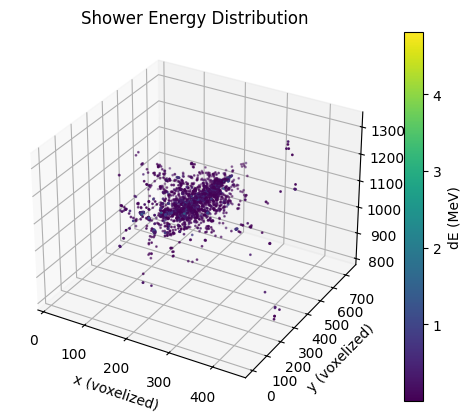

In [24]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

shower = ax.scatter(inputs_masked_x,inputs_masked_y,inputs_masked_z,c=inputs_masked_dE, cmap='viridis', s=1)
ax.set_xlabel('x (voxelized)')
ax.set_ylabel('y (voxelized)')
ax.set_zlabel('z (voxelized)')
ax.set_title('Shower Energy Distribution')
plt.colorbar(shower, ax=ax, label='dE (MeV)')
plt.show()

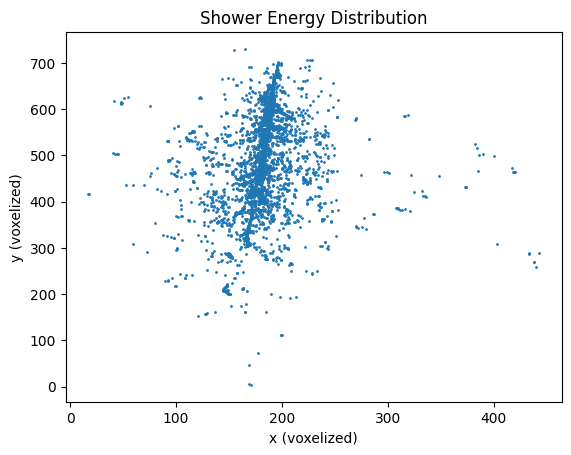

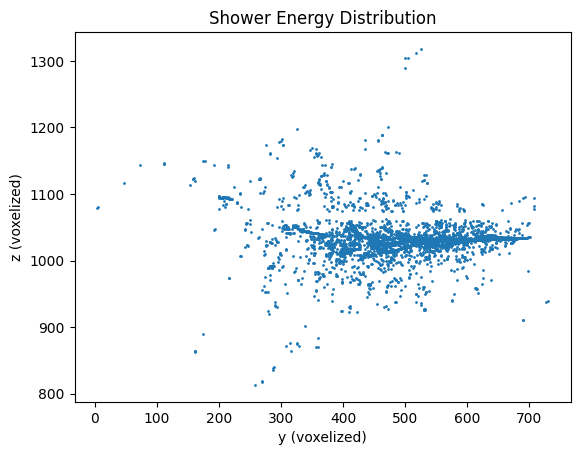

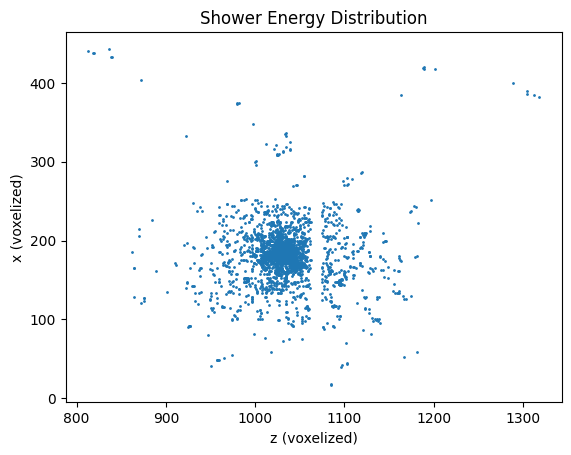

In [25]:
fig = plt.figure()
#ax = fig.add_subplot(projection='3d')

plt.scatter(inputs_masked_x,inputs_masked_y,s=1)
plt.xlabel('x (voxelized)')
plt.ylabel('y (voxelized)')
plt.title('Shower Energy Distribution')
plt.show()

plt.scatter(inputs_masked_y,inputs_masked_z,s=1)
plt.xlabel('y (voxelized)')
plt.ylabel('z (voxelized)')
plt.title('Shower Energy Distribution')
plt.show()

plt.scatter(inputs_masked_z,inputs_masked_x,s=1)
plt.xlabel('z (voxelized)')
plt.ylabel('x (voxelized)')
plt.title('Shower Energy Distribution')
plt.show()

In [5]:
import sys
import importlib
import types
import ROOT
print(types.ModuleType("ROOT"))
#for module in sys.modules:
#    #print("Module:", module)
#    if module == "ROOT":
#        #print(getattr("ROOT", "__spec__", None))
#        print(importlib.util.find_spec("ROOT"))

print("spec:", ROOT.__spec__)
print("file:", getattr(ROOT, "__file__", None))
print("loader:", getattr(ROOT, "__loader__", None))
print("in sys.modules:", "ROOT" in sys.modules)
print(isinstance(ROOT, types.ModuleType))
print(ROOT.gROOT.GetVersion())

<module 'ROOT'>
spec: None
file: /opt/root/lib/ROOT/__init__.py
loader: <_frozen_importlib_external.SourceFileLoader object at 0x7fc8107de530>
in sys.modules: True
True
6.32.02


In [ ]:
# Access LARCV dataset
import yaml
#import ROOT
# Method to get list of files in dataset directory
cfg = """
    input_data:
        parser: sparse3d
        sparse_event: sparse3d_pcluster
    particles:
        parser: particle
        particle_event: particle_pcluster
        sparse_event: sparse3d_pcluster
    meta:
        parser: meta
        sparse_event: sparse3d_pcluster"""
cfg = yaml.safe_load(cfg)
file_list = '/pscratch/sd/e/ehinkle/nd_ana/sheep_single_shower/NDLAR_ELECTRON_SAMPLES/LARCV/electron_NDLAr_10MeVto15GeV_1008TEST.2004.LARCV.root'
larcv_dataset = LArCVDataset(file_keys=file_list, schema=cfg, dtype="float32")
object = larcv_dataset[0]
print(object)


In [5]:
object = larcv_dataset[0]
print(object.keys())
print(len(larcv_dataset))

dict_keys(['index', 'file_index', 'file_entry_index', 'source_file_name', 'source_file_entry_index', 'source_file_size', 'source_file_mtime_ns', 'input_data', 'particles', 'meta'])
50
